In [1]:
import warnings
warnings.filterwarnings("ignore")

# Core
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Preprocessing
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
)
from sklearn.pipeline import Pipeline

# Classification
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    RandomForestRegressor, GradientBoostingRegressor
)
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.svm import SVC, SVR
from sklearn.linear_model import LogisticRegression, Ridge, Lasso, LinearRegression

# Metriques
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    mean_squared_error, mean_absolute_error, r2_score
)


# SHAP
try:
    import shap
    SHAP_AVAILABLE = True
    print("SHAP disponible")
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP non installe -- pip install shap")


SHAP disponible



#  MODULE 2 : Modélisation Supervisée

## Partie 1 : Préparation des Données — Split 70 / 15 / 15 (stratifié)

> **Ratio** : 70% Train | 15% Validation | 15% Test  
> **Stratification** sur `Categorie` pour préserver la distribution des classes.  
> Le **set de validation** sert au tuning, le **test** à l'évaluation finale.

In [2]:
import pandas as pd

df_clean = pd.read_csv("../data/df_clean.csv")

In [3]:
feature_cols = ['Poids', 'Volume','Opacite','Conductivite']

In [4]:
df_clean = df_clean.drop_duplicates(subset=feature_cols, keep='first')

In [5]:
feature_cols = [c for c in df_clean.columns if c not in [
    'Categorie',        
    'Rapport_Collecte', 
    'Prix_Revente'
]]
X = df_clean[feature_cols].copy()
y = df_clean['Categorie'].copy()


# 1. SPLIT d'abord (sur données brutes)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"\nSplit terminé:")
print(f"  Train : {X_train.shape}")
print(f"  Val   : {X_val.shape}")
print(f"  Test  : {X_test.shape}")


Split terminé:
  Train : (1605, 6)
  Val   : (344, 6)
  Test  : (344, 6)



## Mise à l'echelle

In [6]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"\n Standardisation terminée (fit sur Train uniquement)")
print(f"  Train mean: {X_train_scaled.mean():.2e}")
print(f"  Test mean:  {X_test_scaled.mean():.2e}")


 Standardisation terminée (fit sur Train uniquement)
  Train mean: nan
  Test mean:  nan



## Partie 2 : Classification — Entrainement et Evaluation

### 2.1 — Random Forest

In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
print("\n=== RANDOM FOREST ===")

rf = RandomForestClassifier(random_state=42, class_weight='balanced')
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_prec = precision_score(y_test, y_pred_rf, average='weighted')
rf_rec = recall_score(y_test, y_pred_rf, average='weighted')
rf_f1 = f1_score(y_test, y_pred_rf, average='weighted')

print("Confusion matrix RF:\n", confusion_matrix(y_test, y_pred_rf))
print("Accuracy RF:", rf_acc)
print("Precision RF:", rf_prec)
print("Recall RF:", rf_rec)
print("F1-score RF:", rf_f1)

print("\nClassification Report RF:\n")
print(classification_report(y_test, y_pred_rf))


=== RANDOM FOREST ===
Confusion matrix RF:
 [[74  0  0  0  0]
 [ 0 58  0  0  0]
 [ 0  0 93  0  1]
 [ 0  0  0 88  0]
 [ 2  3  5  0 20]]
Accuracy RF: 0.9680232558139535
Precision RF: 0.96795256618208
Recall RF: 0.9680232558139535
F1-score RF: 0.9655321518142139

Classification Report RF:

              precision    recall  f1-score   support

           0       0.97      1.00      0.99        74
           1       0.95      1.00      0.97        58
           2       0.95      0.99      0.97        94
           3       1.00      1.00      1.00        88
           4       0.95      0.67      0.78        30

    accuracy                           0.97       344
   macro avg       0.97      0.93      0.94       344
weighted avg       0.97      0.97      0.97       344



### 2.2 — Gradient Boosting Classifier

In [8]:
gbc = GradientBoostingClassifier(
    n_estimators=50,
    learning_rate=0.05,
    max_depth=2,
    random_state=42
)

gbc.fit(X_train_scaled, y_train)

y_pred_gbc = gbc.predict(X_test_scaled)

gbcl_acc = accuracy_score(y_test, y_pred_gbc)
gbcl_prec = precision_score(y_test, y_pred_gbc, average='weighted')
gbcl_rec = recall_score(y_test, y_pred_gbc, average='weighted')
gbcl_f1 = f1_score(y_test, y_pred_gbc, average='weighted')

print("Confusion Matrix GBC:\n", confusion_matrix(y_test, y_pred_gbc))
print("\nAccuracy GBC:", gbcl_acc)
print("Precision GBC:", gbcl_prec)
print("Recall GBC:", gbcl_rec)
print("F1-score GBC:", gbcl_f1)

print("\nClassification Report GBC:\n")
print(classification_report(y_test, y_pred_gbc))

ValueError: Input X contains NaN.
GradientBoostingClassifier does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

### 2.3 — k-NN (k optimé sur la validation)

In [ ]:
k_range = range(1, 21)
scores = []

for k in k_range:
    knn_tmp = KNeighborsClassifier(n_neighbors=k)
    knn_tmp.fit(X_train_scaled, y_train)
    y_val_pred = knn_tmp.predict(X_val_scaled)
    acc = accuracy_score(y_val, y_val_pred)
    scores.append(acc)

best_k = k_range[scores.index(max(scores))]
print("Meilleur k trouvé =", best_k)

print("\n=== KNN FINAL ===")

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

knn_acc = accuracy_score(y_test, y_pred_knn)
knn_prec = precision_score(y_test, y_pred_knn, average='weighted')
knn_rec = recall_score(y_test, y_pred_knn, average='weighted')
knn_f1 = f1_score(y_test, y_pred_knn, average='weighted')

print("Confusion matrix KNN:\n", confusion_matrix(y_test, y_pred_knn))
print("\nAccuracy KNN:", knn_acc)
print("Precision KNN:", knn_prec)
print("Recall KNN:", knn_rec)
print("F1-score KNN:", knn_f1)

# Classification report
print("\nClassification Report KNN:\n")
print(classification_report(y_test, y_pred_knn))

ValueError: Input X contains NaN.
KNeighborsClassifier does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

### 2.4 — Decision Tree (max_depth optimé)

In [ ]:
print("\n=== DECISION TREE ===")

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train_scaled, y_train)

y_pred_dt = dt.predict(X_test_scaled)

dt_acc = accuracy_score(y_test, y_pred_dt)
dt_prec = precision_score(y_test, y_pred_dt, average='weighted')
dt_rec = recall_score(y_test, y_pred_dt, average='weighted')
dt_f1 = f1_score(y_test, y_pred_dt, average='weighted')

print("Confusion matrix DT:\n", confusion_matrix(y_test, y_pred_dt))
print("Accuracy DT:", dt_acc)
print("Precision DT:", dt_prec)
print("Recall DT:", dt_rec)
print("F1-score DT:", dt_f1)

print("\nClassification Report DT:\n")
print(classification_report(y_test, y_pred_dt))


=== DECISION TREE ===
Confusion matrix DT:
 [[324   0   0   0]
 [  0 315   0   0]
 [  0   0 385   0]
 [  0   0   0 358]]
Accuracy DT: 1.0
Precision DT: 1.0
Recall DT: 1.0
F1-score DT: 1.0

Classification Report DT:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       324
           1       1.00      1.00      1.00       315
           2       1.00      1.00      1.00       385
           3       1.00      1.00      1.00       358

    accuracy                           1.00      1382
   macro avg       1.00      1.00      1.00      1382
weighted avg       1.00      1.00      1.00      1382



### 2.5 — SVM Linéaire

In [ ]:
print("\n=== SVM LINEAR ===")

svm_l = SVC(kernel='linear')
svm_l.fit(X_train_scaled, y_train)

y_pred_svm_l = svm_l.predict(X_test_scaled)

svm_l_acc = accuracy_score(y_test, y_pred_svm_l)
svm_l_prec = precision_score(y_test, y_pred_svm_l, average='weighted')
svm_l_rec = recall_score(y_test, y_pred_svm_l, average='weighted')
svm_l_f1 = f1_score(y_test, y_pred_svm_l, average='weighted')

print("Confusion matrix SVM Linear:\n", confusion_matrix(y_test, y_pred_svm_l))
print("Accuracy:", svm_l_acc)
print("Precision:", svm_l_prec)
print("Recall:", svm_l_rec)
print("F1-score:", svm_l_f1)

print("\nClassification Report SVM Linear:\n")
print(classification_report(y_test, y_pred_svm_l))


=== SVM LINEAR ===
Confusion matrix SVM Linear:
 [[324   0   0   0]
 [  0 315   0   0]
 [  0   1 384   0]
 [  0   0   0 358]]
Accuracy: 0.9992764109985528
Precision: 0.999278700837165
Recall: 0.9992764109985528
F1-score: 0.9992765138914388

Classification Report SVM Linear:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       324
           1       1.00      1.00      1.00       315
           2       1.00      1.00      1.00       385
           3       1.00      1.00      1.00       358

    accuracy                           1.00      1382
   macro avg       1.00      1.00      1.00      1382
weighted avg       1.00      1.00      1.00      1382



### 2.6 — SVM RBF

In [ ]:
print("\n=== SVM RBF ===")

svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train_scaled, y_train)

y_pred_svm_rbf = svm_rbf.predict(X_test_scaled)

svm_rbf_acc = accuracy_score(y_test, y_pred_svm_rbf)
svm_rbf_prec = precision_score(y_test, y_pred_svm_rbf, average='weighted')
svm_rbf_rec = recall_score(y_test, y_pred_svm_rbf, average='weighted')
svm_rbf_f1 = f1_score(y_test, y_pred_svm_rbf, average='weighted')

print("Confusion matrix SVM RBF:\n", confusion_matrix(y_test, y_pred_svm_rbf))
print("Accuracy:", svm_rbf_acc)
print("Precision:", svm_rbf_prec)
print("Recall:", svm_rbf_rec)
print("F1-score:", svm_rbf_f1)

print("\nClassification Report SVM RBF:\n")
print(classification_report(y_test, y_pred_svm_rbf))


=== SVM RBF ===
Confusion matrix SVM RBF:
 [[324   0   0   0]
 [  0 315   0   0]
 [  0   0 385   0]
 [  0   0   0 358]]
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0

Classification Report SVM RBF:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       324
           1       1.00      1.00      1.00       315
           2       1.00      1.00      1.00       385
           3       1.00      1.00      1.00       358

    accuracy                           1.00      1382
   macro avg       1.00      1.00      1.00      1382
weighted avg       1.00      1.00      1.00      1382



### 2.7 — Régression Logistique

In [ ]:
print("\n=== LOGISTIC REGRESSION ===")

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

lr_acc = accuracy_score(y_test, y_pred_lr)
lr_prec = precision_score(y_test, y_pred_lr, average='weighted')
lr_rec = recall_score(y_test, y_pred_lr, average='weighted')
lr_f1 = f1_score(y_test, y_pred_lr, average='weighted')

print("Confusion matrix LR:\n", confusion_matrix(y_test, y_pred_lr))
print("Accuracy:", lr_acc)
print("Precision:", lr_prec)
print("Recall:", lr_rec)
print("F1-score:", lr_f1)

print("\nClassification Report LR:\n")
print(classification_report(y_test, y_pred_lr))


=== LOGISTIC REGRESSION ===
Confusion matrix LR:
 [[324   0   0   0]
 [  0 314   1   0]
 [  0   1 384   0]
 [  0   0   0 358]]
Accuracy: 0.9985528219971056
Precision: 0.9985528219971056
Recall: 0.9985528219971056
F1-score: 0.9985528219971056

Classification Report LR:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       324
           1       1.00      1.00      1.00       315
           2       1.00      1.00      1.00       385
           3       1.00      1.00      1.00       358

    accuracy                           1.00      1382
   macro avg       1.00      1.00      1.00      1382
weighted avg       1.00      1.00      1.00      1382



### 2. — Tableau comparatif des modèles de classification

In [ ]:
results_clf = pd.DataFrame({
    'Accuracy': [rf_acc, gbcl_acc, knn_acc, dt_acc, svm_l_acc, svm_rbf_acc, lr_acc],
    'Precision': [rf_prec, gbcl_prec, knn_prec, dt_prec, svm_l_prec, svm_rbf_prec, lr_prec],
    'Recall': [rf_rec, gbcl_rec, knn_rec, dt_rec, svm_l_rec, svm_rbf_rec, lr_rec],
    'F1-score': [rf_f1, gbcl_f1, knn_f1, dt_f1, svm_l_f1, svm_rbf_f1, lr_f1],
}, index=[
    'Random Forest',
    'Gradient Boosting',
    f'kNN (k={best_k})',
    f'Decision Tree (d=5)',
    'SVM Linear',
    'SVM RBF',
    'Logistic Regression'
]).round(4).sort_values('F1-score', ascending=False)

print("\n=== TABLEAU COMPARATIF ===")
display(results_clf)


=== TABLEAU COMPARATIF ===


,Accuracy,Precision,Recall,F1-score
Random Forest,1.0000,1.0000,1.0000,1.0000
Gradient Boosting,1.0000,1.0000,1.0000,1.0000
kNN (k=1),1.0000,1.0000,1.0000,1.0000
Decision Tree (d=5),1.0000,1.0000,1.0000,1.0000
SVM RBF,1.0000,1.0000,1.0000,1.0000
SVM Linear,0.9993,0.9993,0.9993,0.9993
Logistic Regression,0.9986,0.9986,0.9986,0.9986



## Partie 3 : Sélection de Features avec SHAP Values

> **SHAP** (SHapley Additive exPlanations) mesure la contribution de chaque feature à chaque prédiction.  


=== SHAP Feature Importance ===


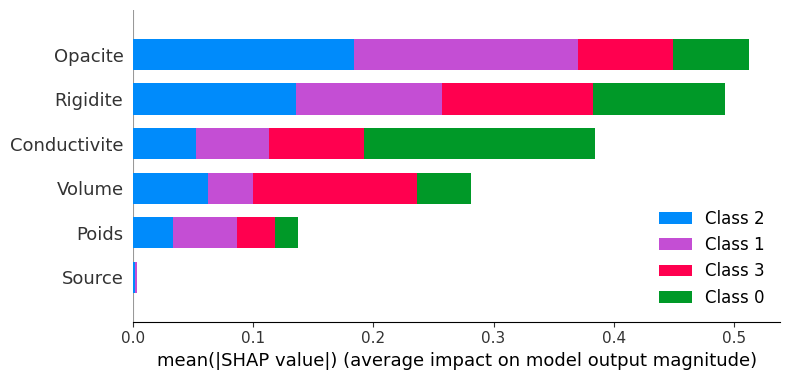


Feature importance SHAP :
Opacite         0.128225
Rigidite        0.123237
Conductivite    0.096118
Volume          0.070235
Poids           0.034359
Source          0.000850
dtype: float64

Features sélectionnées :
['Opacite', 'Rigidite', 'Conductivite', 'Volume']


In [ ]:


print("=== SHAP Feature Importance ===")

# explainer
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_scaled)

# gestion multi-classe
sv = shap_values[0] if isinstance(shap_values, list) else shap_values

# 1. GRAPH SHAP (bar)
shap.summary_plot(
    sv,
    X_test_scaled,
    feature_names=X.columns,
    plot_type="bar",
    show=True
)

# 2. IMPORTANCE SHAP
if sv.ndim == 3:
    importance = np.abs(sv).mean(axis=(0, 2))
else:
    importance = np.abs(sv).mean(axis=0)

shap_importance = pd.Series(
    importance,
    index=X.columns
).sort_values(ascending=False)

print("\nFeature importance SHAP :")
print(shap_importance)

# 3. SELECTION FEATURES
threshold = shap_importance.quantile(0.25)
selected_features = shap_importance[shap_importance > threshold].index.tolist()

print("\nFeatures sélectionnées :")
print(selected_features)


##  Tuning des Hyperparamètres

### 5.1 — GridSearchCV 

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

print("\n=== GRIDSEARCH Random Forest ===")

# paramètres (réduits pour éviter lenteur)
parameters = {
    'n_estimators': [100, 150],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

# modèle
model = RandomForestClassifier(random_state=42, class_weight='balanced')

# GridSearch (style prof)
clf = GridSearchCV(
    model,
    parameters,
    scoring='f1_weighted',
    cv=5
)

grille = clf.fit(X_train_scaled, y_train)

# meilleurs paramètres
print("Best params:", grille.best_params_)
print("Best CV score:", grille.best_score_)

# prédiction
y_pred_rf_grid = grille.predict(X_test_scaled)

# métriques
rf_grid_acc = accuracy_score(y_test, y_pred_rf_grid)
rf_grid_prec = precision_score(y_test, y_pred_rf_grid, average='weighted')
rf_grid_rec = recall_score(y_test, y_pred_rf_grid, average='weighted')
rf_grid_f1 = f1_score(y_test, y_pred_rf_grid, average='weighted')

print('Confusion matrix RF \n', confusion_matrix(y_test, y_pred_rf_grid))
print('Accuracy RF', rf_grid_acc)
print('Precision RF', rf_grid_prec)
print('Recall RF', rf_grid_rec)
print('F1-score RF', rf_grid_f1)


=== GRIDSEARCH Random Forest ===
Best params: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 150}
Best CV score: 1.0
Confusion matrix RF 
 [[324   0   0   0]
 [  0 315   0   0]
 [  0   0 385   0]
 [  0   0   0 358]]
Accuracy RF 1.0
Precision RF 1.0
Recall RF 1.0
F1-score RF 1.0


### 5.2 — Optuna (Bayesian Optimization / TPE)

> **Optuna** utilise le TPE (Tree-structured Parzen Estimator) pour explorer intelligemment  
> l'espace des hyperparamètres, bien plus efficace que la grille exhaustive pour les grands espaces.

In [ ]:
import optuna
from sklearn.model_selection import cross_val_score

print("\n=== Optuna - Random Forest ===")

def objective(trial):

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 5, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
    }

    model = RandomForestClassifier(
        **params,
        random_state=42,
        class_weight='balanced'
    )

    score = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5,  # plus rapide
        scoring='f1_weighted'
    ).mean()

    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)  # rapide

best_params = study.best_params

best_rf_opt = RandomForestClassifier(
    **best_params,
    random_state=42,
    class_weight='balanced'
)

best_rf_opt.fit(X_train_scaled, y_train)

y_pred_opt = best_rf_opt.predict(X_test_scaled)

# métriques
opt_acc = accuracy_score(y_test, y_pred_opt)
opt_prec = precision_score(y_test, y_pred_opt, average='weighted')
opt_rec = recall_score(y_test, y_pred_opt, average='weighted')
opt_f1 = f1_score(y_test, y_pred_opt, average='weighted')

print("\nBest Optuna params:", best_params)
print("Best CV F1:", study.best_value)
print("Test F1:", opt_f1)
print("Test Acc:", opt_acc)

[I 2026-05-05 23:44:29,112] A new study created in memory with name: no-name-72e294de-221c-4a80-b7ae-c69c324500b2



=== Optuna - Random Forest ===


[I 2026-05-05 23:44:30,210] Trial 0 finished with value: 1.0 and parameters: {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 8}. Best is trial 0 with value: 1.0.
[I 2026-05-05 23:44:31,809] Trial 1 finished with value: 1.0 and parameters: {'n_estimators': 149, 'max_depth': 12, 'min_samples_split': 4}. Best is trial 0 with value: 1.0.
[I 2026-05-05 23:44:32,886] Trial 2 finished with value: 1.0 and parameters: {'n_estimators': 85, 'max_depth': 14, 'min_samples_split': 3}. Best is trial 0 with value: 1.0.
[I 2026-05-05 23:44:33,931] Trial 3 finished with value: 1.0 and parameters: {'n_estimators': 87, 'max_depth': 12, 'min_samples_split': 10}. Best is trial 0 with value: 1.0.
[I 2026-05-05 23:44:35,497] Trial 4 finished with value: 1.0 and parameters: {'n_estimators': 122, 'max_depth': 7, 'min_samples_split': 9}. Best is trial 0 with value: 1.0.
[I 2026-05-05 23:44:37,444] Trial 5 finished with value: 1.0 and parameters: {'n_estimators': 140, 'max_depth': 9, 'min_samples_spli


Best Optuna params: {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 8}
Best CV F1: 1.0
Test F1: 1.0
Test Acc: 1.0


### 5.3 — Comparaison : Baseline vs GridSearch vs Optuna

In [ ]:
print("\n=== COMPARAISON FINALE TUNING ===")

comparison = pd.DataFrame({
    'Modèle': [
        'Random Forest (Baseline)',
        'Random Forest (GridSearch)',
        'Random Forest (Optuna)'
    ],
    'F1-score': [
        rf_f1,        # baseline
        rf_grid_f1,   # grid
        opt_f1        # optuna
    ],
    'Accuracy': [
        rf_acc,
        rf_grid_acc,
        opt_acc
    ]
}).sort_values('F1-score', ascending=False)

display(comparison)


=== COMPARAISON FINALE TUNING ===


,Modèle,F1-score,Accuracy
0,Random Forest (Baseline),1.0,1.0
1,Random Forest (GridSearch),1.0,1.0
2,Random Forest (Optuna),1.0,1.0


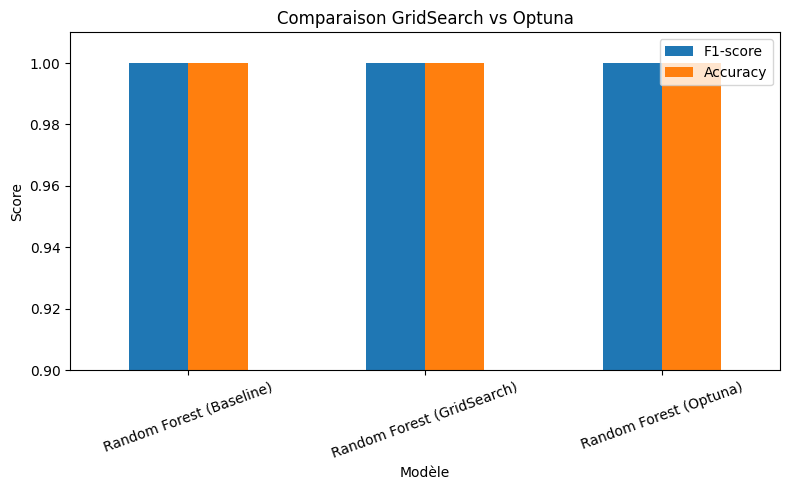

In [ ]:
comparison.set_index('Modèle').plot(kind='bar', figsize=(8,5))
plt.title("Comparaison GridSearch vs Optuna")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.ylim(0.9, 1.01)
plt.tight_layout()
plt.show()